In [3]:
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Define the model architecture (needs to match exactly what was used for training)
class AttentionGate(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(AttentionGate, self).__init__()
        self.theta_x = torch.nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.phi_g = torch.nn.Conv2d(out_channels, out_channels, kernel_size=1)
        self.psi = torch.nn.Conv2d(out_channels, 1, kernel_size=1)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x, g):
        theta_x = self.theta_x(x)
        phi_g = self.phi_g(g)
        add_xg = theta_x + phi_g
        act_xg = torch.nn.functional.relu(add_xg, inplace=True)
        psi = self.psi(act_xg)
        sigmoid_xg = self.sigmoid(psi)
        return x * sigmoid_xg

class ConvBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class AttentionUNet(torch.nn.Module):
    def __init__(self, in_channels=4, out_channels=3):
        super(AttentionUNet, self).__init__()
        # Encoder
        self.c1 = ConvBlock(in_channels, 64)
        self.pool1 = torch.nn.MaxPool2d(2)
        self.c2 = ConvBlock(64, 128)
        self.pool2 = torch.nn.MaxPool2d(2)
        
        # Bottleneck
        self.c3 = ConvBlock(128, 256)
        
        # Decoder
        self.up4 = torch.nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att4 = AttentionGate(128, 128)
        self.c4 = ConvBlock(256, 128)
        self.up5 = torch.nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att5 = AttentionGate(64, 64)
        self.c5 = ConvBlock(128, 64)
        
        # Output
        self.out = torch.nn.Conv2d(64, out_channels, kernel_size=1)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Encoder
        c1 = self.c1(x)
        p1 = self.pool1(c1)
        c2 = self.c2(p1)
        p2 = self.pool2(c2)
        
        # Bottleneck
        c3 = self.c3(p2)
        
        # Decoder
        u4 = self.up4(c3)
        att4 = self.att4(c2, u4)
        c4 = self.c4(torch.cat([u4, att4], dim=1))
        u5 = self.up5(c4)
        att5 = self.att5(c1, u5)
        c5 = self.c5(torch.cat([u5, att5], dim=1))
        # Output
        out = self.out(c5)
        return self.sigmoid(out)

# Function to load and process Sentinel-2 data
def process_sentinel2_image(model, input_file_path):
    """
    Process a Sentinel-2 image using the trained model
    
    Args:
        model: Trained AttentionUNet model
        input_file_path: Path to the input Sentinel-2 data (.npy file)
        
    Returns:
        Prediction as numpy array with shape (H, W, 3)
    """
    # Load input data
    input_data = np.load(input_file_path)  # Expected shape: (H, W, 4)
    
    # Prepare input tensor
    input_tensor = torch.from_numpy(input_data).permute(2, 0, 1).float().unsqueeze(0)  # (1, 4, H, W)
    
    # Move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_tensor = input_tensor.to(device)
    
    # Set model to evaluation mode
    model.eval()
    
    # Make prediction
    with torch.no_grad():
        output = model(input_tensor)
    
    # Convert output to numpy array
    prediction = output.squeeze(0).permute(1, 2, 0).cpu().numpy()  # (H, W, 3)
    
    return prediction

# Function to visualize results
def visualize_results(input_image, predicted_output, ground_truth=None):
    """
    Visualize the input, prediction, and optionally the ground truth
    
    Args:
        input_image: Input Sentinel-2 image as numpy array (H, W, 4)
        predicted_output: Predicted output as numpy array (H, W, 3)
        ground_truth: Optional ground truth as numpy array (H, W, 3)
    """
    plt.figure(figsize=(15, 5))
    
    # Display input (RGB composite from the 4 channels)
    plt.subplot(1, 3 if ground_truth is not None else 2, 1)
    # Use first 3 channels as RGB (or modify according to your band arrangement)
    rgb_input = input_image[:, :, :3]  # Assuming first 3 channels can form an RGB
    plt.imshow(rgb_input / rgb_input.max())  # Normalize for visualization
    plt.title('Input (RGB Composite)')
    plt.axis('off')
    
    # Display prediction
    plt.subplot(1, 3 if ground_truth is not None else 2, 2)
    plt.imshow(predicted_output)
    plt.title('Predicted Output')
    plt.axis('off')
    
    # Display ground truth if available
    if ground_truth is not None:
        plt.subplot(1, 3, 3)
        plt.imshow(ground_truth)
        plt.title('Ground Truth')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()



Using device: cpu
Model loaded from attention_unet_best.pth
Processing training_patches\test\inputs\patch_0.npy


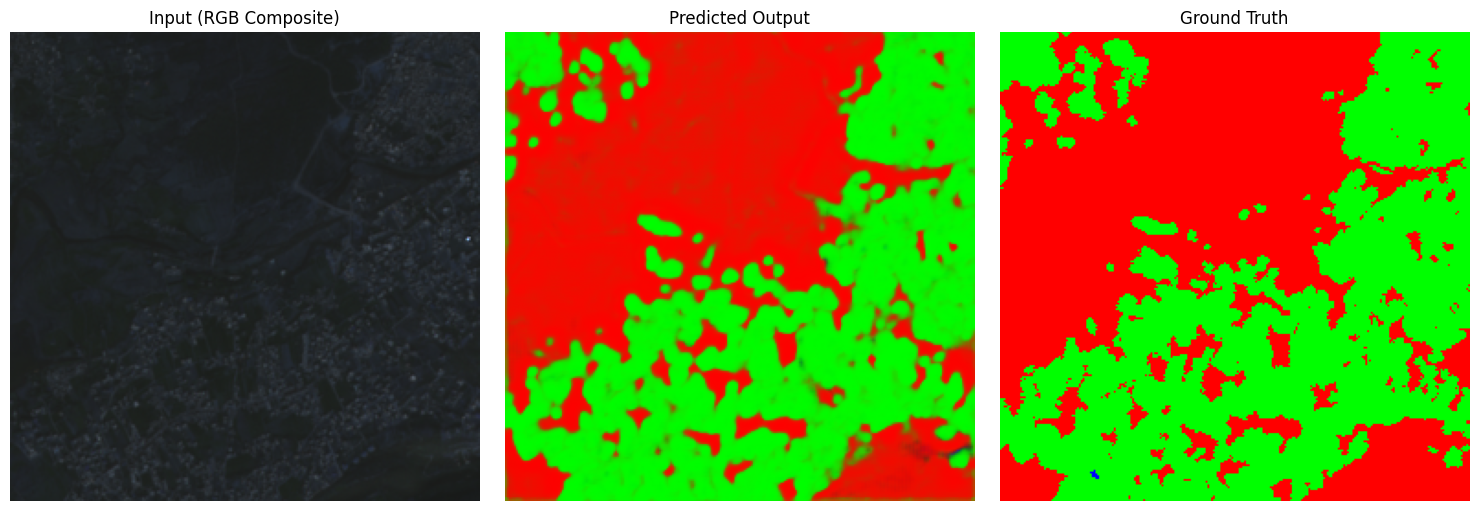

Prediction shape: (256, 256, 3)
Prediction range: Min=0.0000, Max=1.0000
Prediction data type: float32
Processing training_patches\test\inputs\patch_1.npy


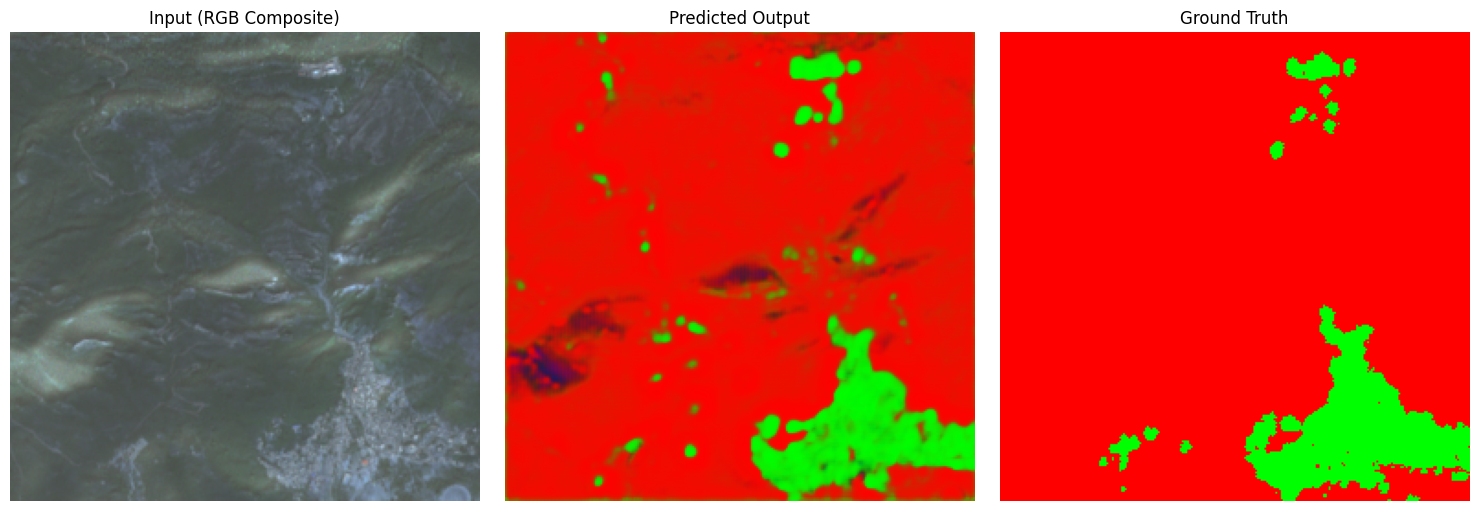

Prediction shape: (256, 256, 3)
Prediction range: Min=0.0000, Max=0.9998
Prediction data type: float32
Processing training_patches\test\inputs\patch_10.npy


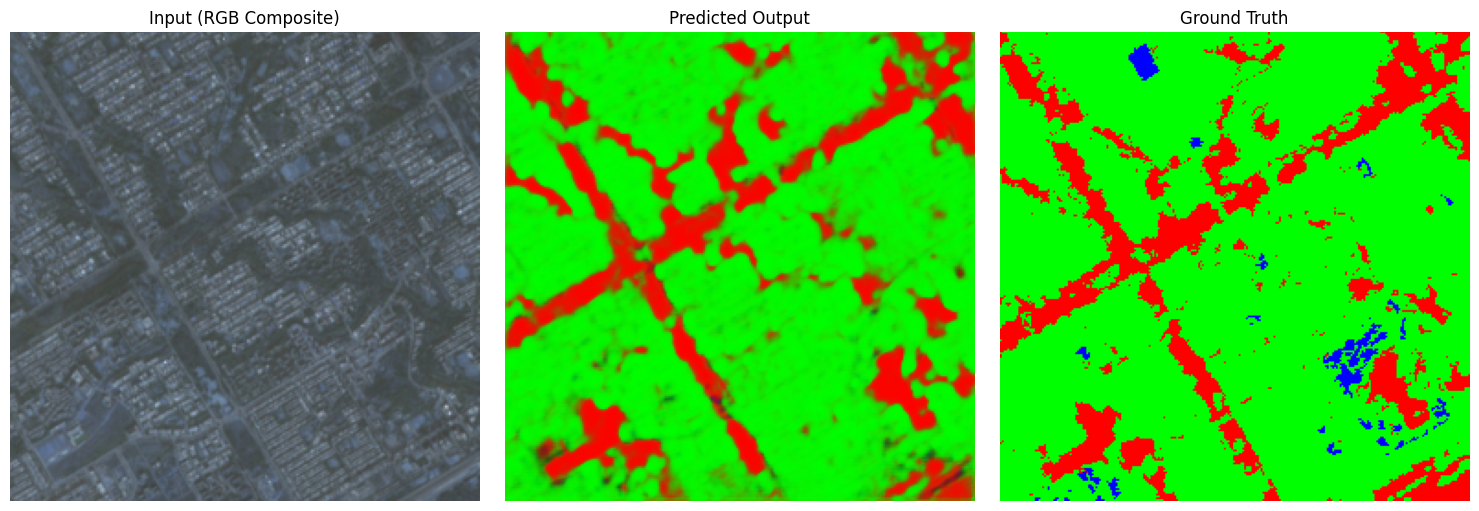

Prediction shape: (256, 256, 3)
Prediction range: Min=0.0000, Max=1.0000
Prediction data type: float32
Processing training_patches\test\inputs\patch_100.npy


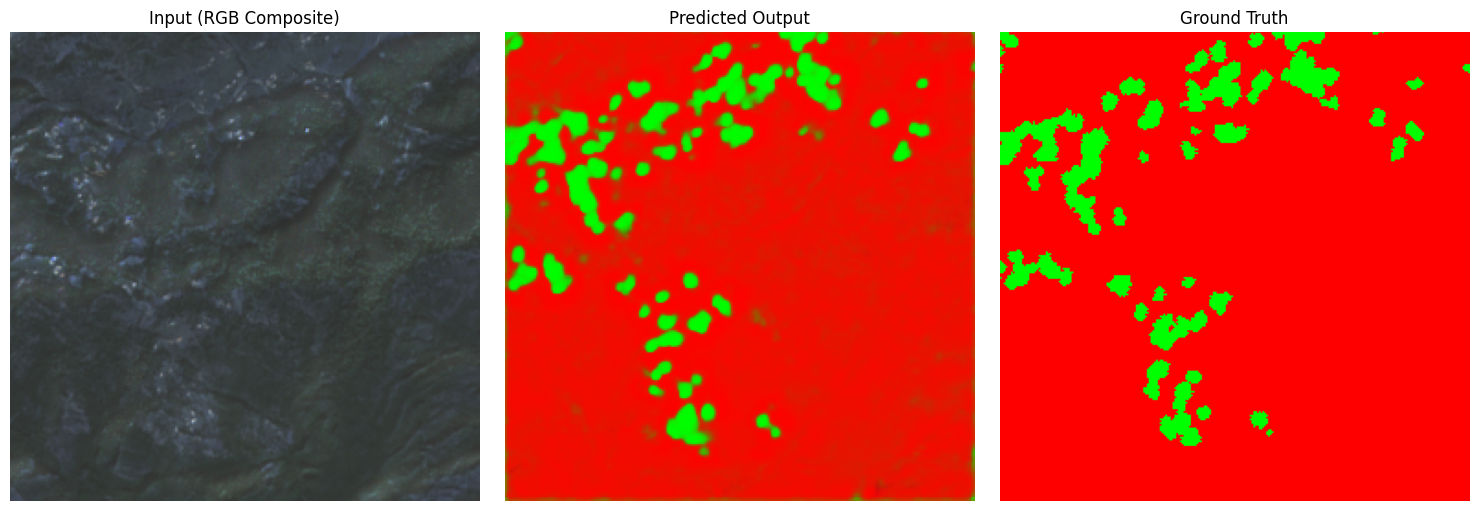

Prediction shape: (256, 256, 3)
Prediction range: Min=0.0000, Max=1.0000
Prediction data type: float32
Processing training_patches\test\inputs\patch_101.npy


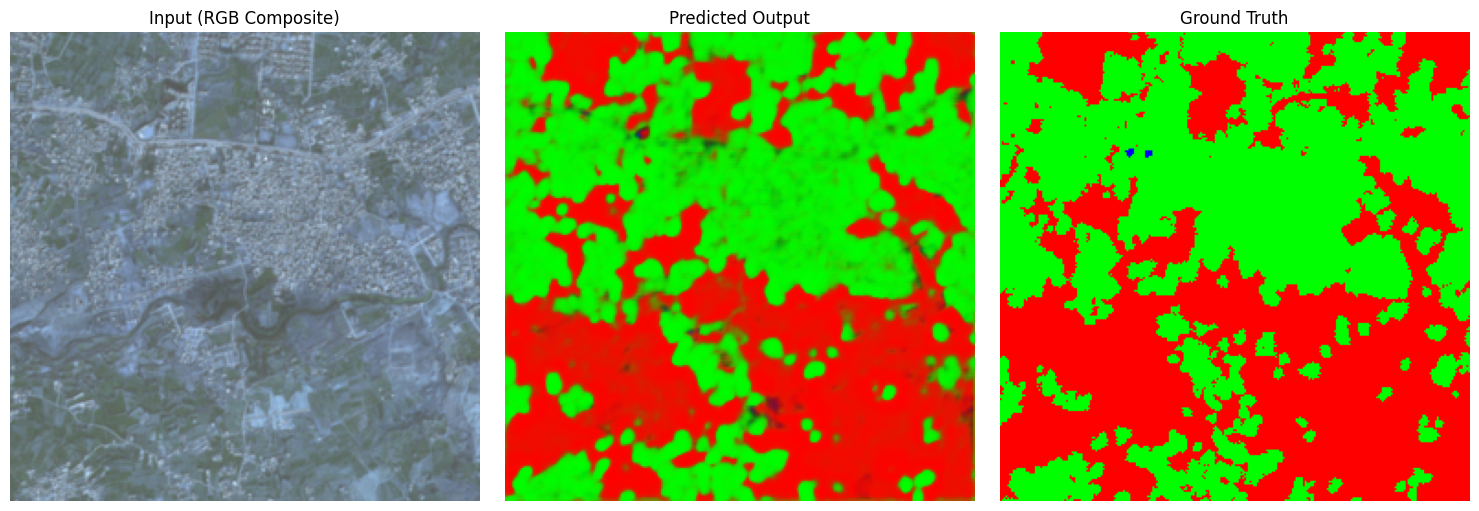

Prediction shape: (256, 256, 3)
Prediction range: Min=0.0000, Max=1.0000
Prediction data type: float32


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model
model_path = 'attention_unet_best.pth'
model = AttentionUNet(in_channels=4, out_channels=3).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
print(f"Model loaded from {model_path}")

# Process test data
test_data_dir = Path('training_patches/test/inputs')
test_label_dir = Path('training_patches/test/labels')

# Process a few test samples
for i, input_file in enumerate(list(test_data_dir.glob('patch_*.npy'))[:5]):  # Process first 5 samples
    print(f"Processing {input_file}")
    
    # Load input data
    input_data = np.load(input_file)
    
    # Get corresponding ground truth if available
    label_file = test_label_dir / input_file.name
    ground_truth = np.load(label_file) if label_file.exists() else None
    
    # Process image
    prediction = process_sentinel2_image(model, input_file)
    
    # Visualize
    visualize_results(input_data, prediction, ground_truth)
    
    # Print some statistics
    print(f"Prediction shape: {prediction.shape}")
    print(f"Prediction range: Min={prediction.min():.4f}, Max={prediction.max():.4f}")
    print(f"Prediction data type: {prediction.dtype}")
    
    if i >= 4:  # Limit to 5 samples
        break